<a href="https://colab.research.google.com/github/IIC1005/VC/blob/main/Experiencia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

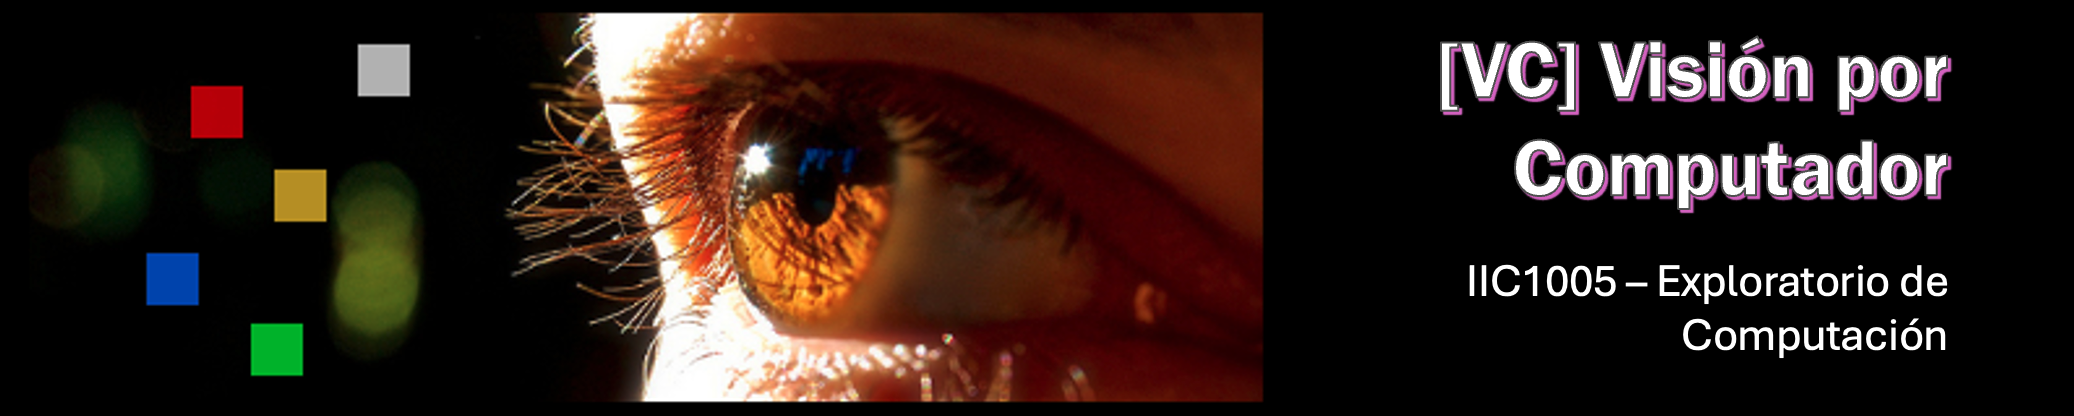

Basado en el material de  [Domingo Mery](https://domingomery.ing.puc.cl/) - Department of Computer Science - Universidad Católica de Chile

# **ACTIVIDAD**: Comparar Persona 1 vs Persona 2

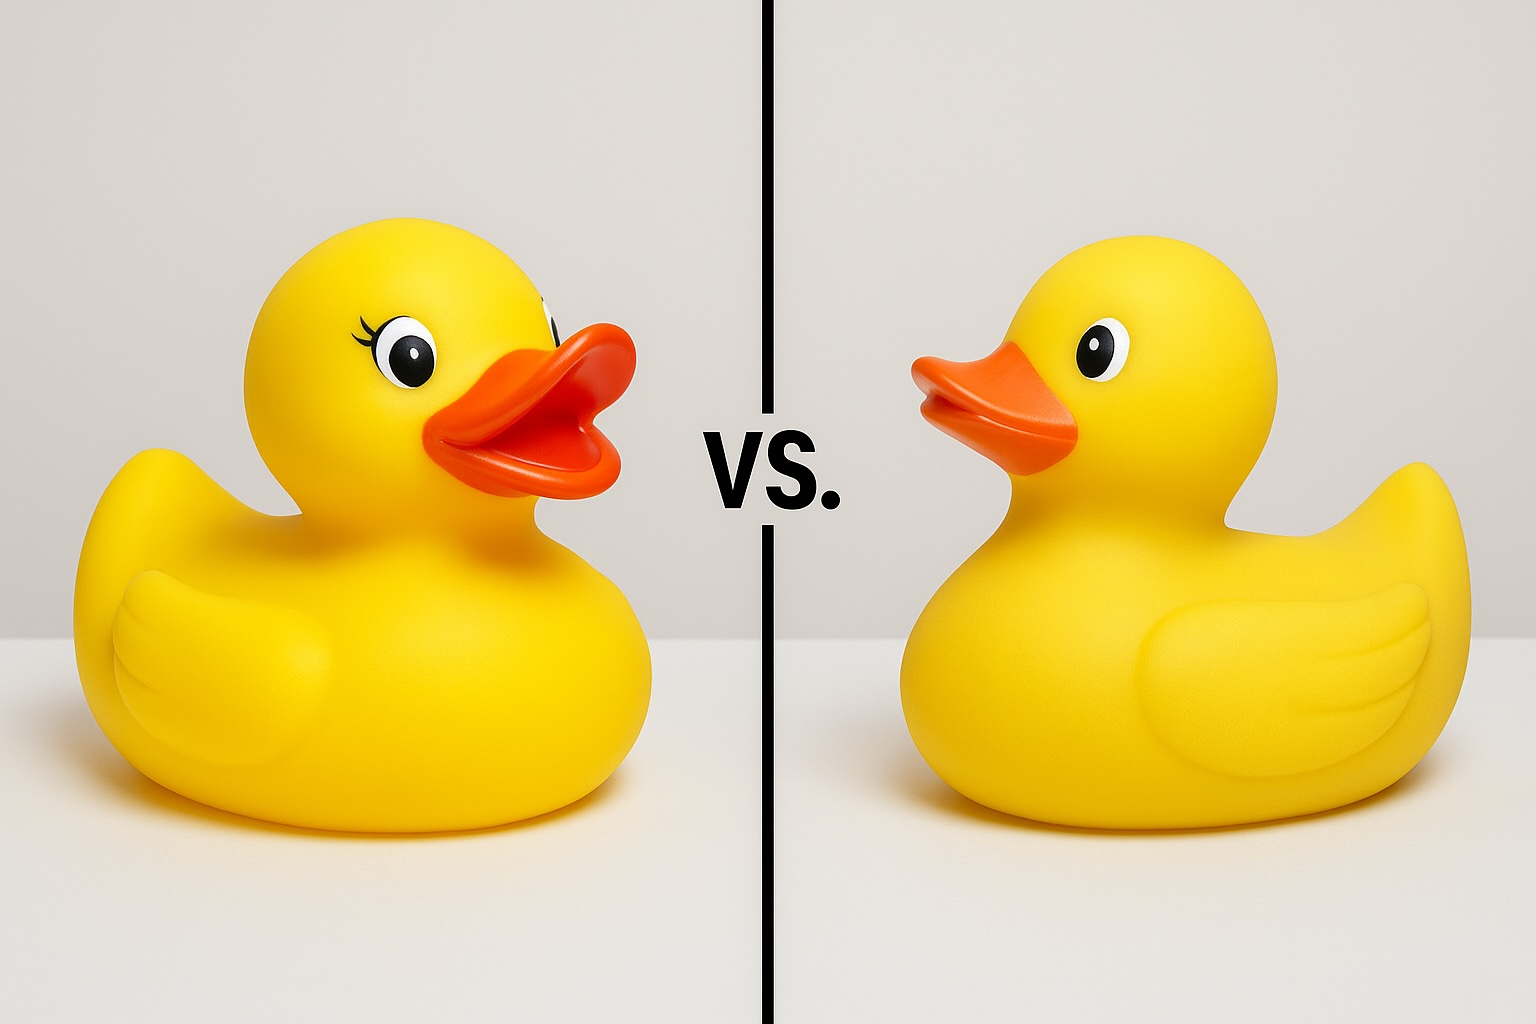

# <font color='orange'>Recuerda el Código de Ética de Jagadish(+):

1. No sorprender:

No se debe sorprender al sujeto de los datos con los datos (sobre el sujeto) que usted recogió, compartió o utilizó.

2. Sea dueño de los resultados:

Si el proceso conduce a resultados indeseables, se debe trabajar para modificar el proceso aunque no haya nada "malo" en él.



(+) *From: Course ‘Data Science Ethics’ by University of Michigan. Prof. H.V. Jagadish*

# ANTES DE COMENZAR

Por favor ejecute las siguientes celdas que contiene todas las librerías que se utilizarán en este ejercicio.

<font color='red'> **NO USAR OTRAS LIBRERÍAS**

#1) Instalar Librerias

In [ ]:
# Instalación de Librería de Reconocimiento Facial
!git clone https://github.com/mk-minchul/AdaFace
!mkdir /content/AdaFace/pretrained
!wget https://www.dropbox.com/scl/fi/5pvwapkas67jy9ypoarx3/adaface_ir50_ms1mv2.ckpt?rlkey=kgnqrjajlj2yt2c17dq8zn33r
!mv adaface_ir50_ms1mv2.ckpt?rlkey=kgnqrjajlj2yt2c17dq8zn33r /content/AdaFace/pretrained/adaface_ir50_ms1mv2.ckpt
!pip install pytorch-lightning

Cloning into 'AdaFace'...
remote: Enumerating objects: 236, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 236 (delta 66), reused 56 (delta 56), pack-reused 129 (from 1)
Receiving objects: 100% (236/236), 38.95 MiB | 28.11 MiB/s, done.
Resolving deltas: 100% (88/88), done.
mkdir: cannot create directory ‘/content/AdaFace/pretrained’: File exists
--2025-10-22 10:07:28--  https://www.dropbox.com/scl/fi/5pvwapkas67jy9ypoarx3/adaface_ir50_ms1mv2.ckpt?rlkey=kgnqrjajlj2yt2c17dq8zn33r
Resolving www.dropbox.com (www.dropbox.com)... 162.125.65.18, 2620:100:6017:18::a27d:212
Connecting to www.dropbox.com (www.dropbox.com)|162.125.65.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uccb421d3154a6ebdee4136c8786.dl.dropboxusercontent.com/cd/0/inline/CzvPqK0a7xJIJY9INJoXZ2etKFwR63bYcJCS6Pu2Irm-psbBxZ9lIusPi1mIEn9KC_mpkmedXF4JmK_sv_YMyezKsopDysij-8HV0DXKsznXL5POOMwOYRn26Qfey3v44dk/file# [fol

In [ ]:
!pip3 install mtcnn
!pip3 install opencv-contrib-python

In [ ]:
import cv2 # Librería OpenCV
import matplotlib.pyplot as plt
import numpy as np # Librería de Matemáticas
from tqdm.auto import tqdm
import os, fnmatch
from mtcnn.mtcnn import MTCNN
from PIL import Image

# 2) Functiones Para Cortar Caras y Extraer Embeddings



In [ ]:
detector = MTCNN()

In [ ]:
def crop(path):
  # Leer imágen original
  Ao = cv2.imread(path)
  # Cortar cara
  face_locations = detector.detect_faces(Ao)
  bb = face_locations[0]['box']
  x1 = bb[0]
  x2 = bb[0]+bb[2]
  y1 = bb[1]
  y2 = bb[1]+bb[3]
  A = Ao[y1:y2,x1:x2,:]
  return A

In [ ]:
%cd /content/AdaFace
# Cargamos modelo pre-entrenado
from face_alignment import align
from inference import load_pretrained_model, to_input
import torch
from pytorch_lightning.callbacks import ModelCheckpoint

torch.serialization.add_safe_globals([ModelCheckpoint])

model = load_pretrained_model('ir_50')

/content/AdaFace


In [ ]:
# Función para usar modelo reconecedor
def fx_adaface(A):
  img       = cv2.resize(A, (112,112))
  coverted  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  pil_image = Image.fromarray(coverted)
  bgr_input = to_input(pil_image)
  features, _ = model(bgr_input)
  X = features.detach()
  X = X.numpy()
  return X

# 3) Descargando ejemplos

En este set de datos encontrarás:
* Pares de diferentes celebridades que se parecen y pares de fotos de la misma celebridad en diferentes momentos de su vida.
Ubicado en `content/fotos/celebritiespairs/`.

In [ ]:
!wget -O /content/VCfotos.zip https://www.dropbox.com/scl/fi/xk8o853izmdoowapk0kdb/VCfotos.zip?rlkey=qsd0lfow0g17zha8glt8q5edk&dl=1
!unzip -qq /content/VCfotos.zip -d /content

--2025-10-22 10:08:26--  https://www.dropbox.com/scl/fi/xk8o853izmdoowapk0kdb/VCfotos.zip?rlkey=qsd0lfow0g17zha8glt8q5edk
Resolving www.dropbox.com (www.dropbox.com)... 162.125.2.18, 2620:100:6017:18::a27d:212
Connecting to www.dropbox.com (www.dropbox.com)|162.125.2.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uca5cc030d144bbcc655b1a53946.dl.dropboxusercontent.com/cd/0/inline/CztcuxrYA774mJotZz3AQqPbGxxVtEly7Tv-gKybJxJcs2N38NijTjjEtWWDxmsVvSY4TmhhaR4Zce44_nd63OWYiOybeH8QiktwwFI_nyEpkTbwjBjmA9u6qVlgvImfyH0/file# [following]
--2025-10-22 10:08:26--  https://uca5cc030d144bbcc655b1a53946.dl.dropboxusercontent.com/cd/0/inline/CztcuxrYA774mJotZz3AQqPbGxxVtEly7Tv-gKybJxJcs2N38NijTjjEtWWDxmsVvSY4TmhhaR4Zce44_nd63OWYiOybeH8QiktwwFI_nyEpkTbwjBjmA9u6qVlgvImfyH0/file
Resolving uca5cc030d144bbcc655b1a53946.dl.dropboxusercontent.com (uca5cc030d144bbcc655b1a53946.dl.dropboxusercontent.com)... 162.125.2.15, 2620:100:6017:15::a27d:20f
Connecting to uca5cc03

#4) Comparando


`X` y `Y` son multiplicados correctamente para encontrar el score entre Persona 1 y Persona 2. Para esto, ambas fotos son cosideradas de la misma persona si el score es mayor a 0.33.

score = 0.1879187375307083
¿Son la misma persona?: False


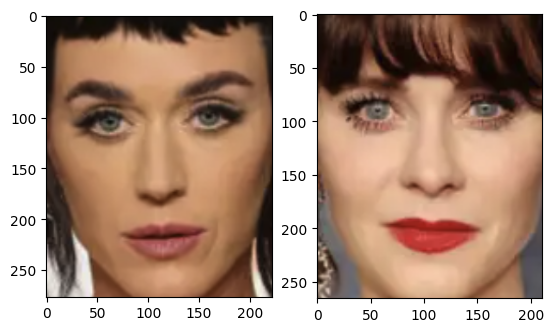

In [ ]:
#  CAMBIAR POR SUS FOTOS  ################
Person1Path = "/content/fotos/celebritiespairs/02-perry.png"
Person2Path = "/content/fotos/celebritiespairs/02-zooey.png"
th = 0.33 # Threshold para aceptar match
###########################

A1 = crop(Person1Path)
A2 = crop(Person2Path)

X1 = fx_adaface(A1)
X2 = fx_adaface(A2)

score = np.dot(X1, X2.T)
detect = score > th

fig = plt.figure()
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)
ax1.imshow(cv2.cvtColor(A1, cv2.COLOR_BGR2RGB))
ax2.imshow(cv2.cvtColor(A2, cv2.COLOR_BGR2RGB))

print(f"score = {score[0][0]}")
print(f"¿Son la misma persona?: {detect[0][0]}")

#5) Evaluando Limitaciones


Modificaremos una imágen con distintos filtros y evaluaremos como afectan a la detección de caras.

In [ ]:
# Funcion para aplicar transformaciones
def apply_transformations(image, config):
    img = image.copy()

    # Rotation
    if config["rotation"][0]:
        angle = config["rotation"][1]
        (h, w) = img.shape[:2]
        M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
        img = cv2.warpAffine(img, M, (w, h))

    # Noise
    if config["noise"][0]:
        std = config["noise"][1]
        noise = np.random.normal(0, std, img.shape).astype(np.float32)
        img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    # Blur
    if config["blur"][0]:
        k = int(config["blur"][1])
        if k % 2 == 0: k += 1
        img = cv2.GaussianBlur(img, (k, k), 0)

    # Brightness
    if config["brightness"][0]:
        alpha = config["brightness"][1]
        img = cv2.convertScaleAbs(img, alpha=alpha, beta=0)

    # Contrast
    if config["contrast"][0]:
        c = config["contrast"][1]
        img = np.clip(127 + c * (img - 127), 0, 255).astype(np.uint8)

    # Grayscale
    if config["grayscale"][0]:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    # Sepia
    if config["sepia"][0]:
        kernel = np.array([[0.272, 0.534, 0.131],
                           [0.349, 0.686, 0.168],
                           [0.393, 0.769, 0.189]])
        img = np.clip(cv2.transform(img, kernel), 0, 255).astype(np.uint8)

    # Flip
    if config["flip"][0]:
        direction = config["flip"][1]
        img = cv2.flip(img, direction)

    # Crop
    if config["crop"][0]:
        frac = config["crop"][1]
        h, w = img.shape[:2]
        dx, dy = int(w*frac), int(h*frac)
        img = img[dy:h-dy, dx:w-dx]
        img = cv2.resize(img, (w, h))

    # JPEG compression
    if config["jpeg_compression"][0]:
        quality = int(config["jpeg_compression"][1])
        encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
        _, enc = cv2.imencode('.jpg', img, encode_param)
        img = cv2.imdecode(enc, cv2.IMREAD_COLOR)

    # Color shift
    if config["color_shift"][0]:
        shift = config["color_shift"][1]
        shifts = np.random.randint(-shift, shift+1, size=3)
        img = np.clip(img + shifts, 0, 255).astype(np.uint8)

    return img

 ## 5.1) INSTRUCCIONES  
 Activa o desactiva cada transformación cambiando True o False.
 El número controla la intensidad o valor del cambio.

 Ejemplos:
   - "rotation": (True, 30)    → se aplica rotación y rota 30°
   - "blur": (True, 5)         → se aplica desenfoca con factor de 5
   - "flip": (False, 1)         → No se aplica flip de imagen

In [ ]:
################  CAMBIAR POR SU FOTO  ################
PhotoPath = "/content/fotos/celebritiespairs/02-perry.png"
#######################################################


################ ELEGIR TRANSFORMACIONES ##############
transformations_config = {
    "rotation": (False, 0),          # grados de rotacion
    "noise": (False, 1),             # desviacion estandar
    "blur": (False, 7),               # kernel size (debe ser impar)
    "brightness": (False, 1),       # 1 = normal, < 1 más oscuro, > 1 más claro
    "contrast": (False, 1),         # 1 = normal, >1 más contraste
    "grayscale": (False, 1),         # 1 = aplicar
    "sepia": (False, 1),             # 1 = aplicar
    "flip": (False, 1),               # 1 = horizontal, 0 = vertical
    "crop": (False, 0),            # fraccion a cortar de cada lado (0–0.4)
    "jpeg_compression": (False, 0),  # calidad de imagen (mas pequeño = peor calidad)
    "color_shift": (False, 0)        # shiftea el color de la imagen por +- el valor entregado
}
########################################################


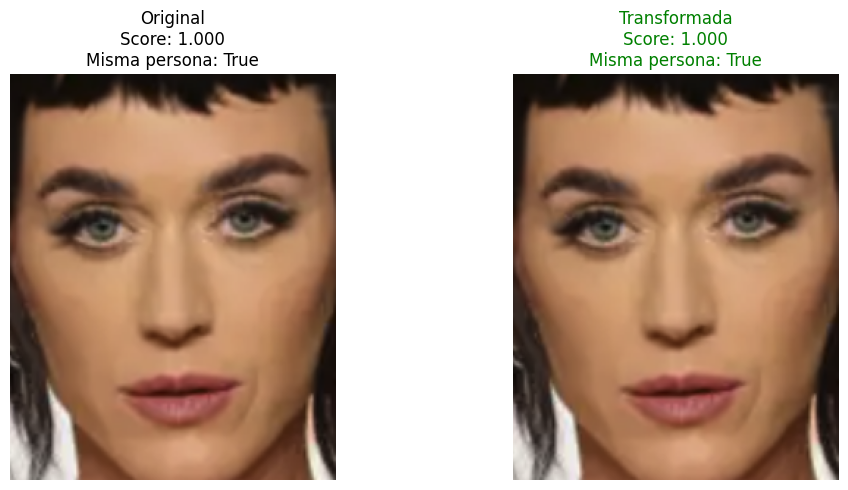

In [ ]:

# Cortamos caras a foto original, creamos foto transformada y calculamos score
original = crop(PhotoPath)
transformed = apply_transformations(original, transformations_config)

orig_feat = fx_adaface(original)
trans_feat = fx_adaface(transformed)

score =  np.dot(orig_feat, trans_feat.T)
same_person = score >= th

# Mostramos las imagenes
fig, axs = plt.subplots(1, 2, figsize=(11, 5))
axs[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
axs[0].set_title(f"Original\nScore: 1.000\nMisma persona: True")
axs[0].axis("off")

axs[1].imshow(cv2.cvtColor(transformed, cv2.COLOR_BGR2RGB))
axs[1].set_title(
    f"Transformada\nScore: {score[0][0]:.3f}\nMisma persona: {same_person[0][0]}",
    color=("green" if same_person else "red")
)
axs[1].axis("off")

plt.tight_layout()
plt.show()
